In [37]:
import pandas as pd
df = pd.read_csv('../data/data.csv')
df.head()

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,1.0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2.0,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,NaN,Car,Semiurban,Graduate,NaN,Private,No
2,3.0,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,NaN,Urban,NaN,Female,Government,Yes
3,4.0,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,5.0,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,NaN,Graduate,Male,Private,Yes


In [38]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_ID        950 non-null    float64
 1   Applicant_Income    950 non-null    float64
 2   Coapplicant_Income  950 non-null    float64
 3   Employment_Status   950 non-null    str    
 4   Age                 950 non-null    float64
 5   Marital_Status      950 non-null    str    
 6   Dependents          950 non-null    float64
 7   Credit_Score        950 non-null    float64
 8   Existing_Loans      950 non-null    float64
 9   DTI_Ratio           950 non-null    float64
 10  Savings             950 non-null    float64
 11  Collateral_Value    950 non-null    float64
 12  Loan_Amount         950 non-null    float64
 13  Loan_Term           950 non-null    float64
 14  Loan_Purpose        950 non-null    str    
 15  Property_Area       950 non-null    str    
 16  Education_Level   

In [39]:
df.isnull().sum()

Applicant_ID          50
Applicant_Income      50
Coapplicant_Income    50
Employment_Status     50
Age                   50
Marital_Status        50
Dependents            50
Credit_Score          50
Existing_Loans        50
DTI_Ratio             50
Savings               50
Collateral_Value      50
Loan_Amount           50
Loan_Term             50
Loan_Purpose          50
Property_Area         50
Education_Level       50
Gender                50
Employer_Category     50
Loan_Approved         50
dtype: int64

In [40]:
df.shape
df = df.dropna(subset=['Loan_Approved'])
df.shape

(950, 20)

In [41]:
from sklearn.impute import SimpleImputer

categorical_cols = df.select_dtypes(include='object').columns.drop('Loan_Approved')
numerical_cols = df.select_dtypes(include='number').columns

categorical_cols

C:\Users\upate\AppData\Local\Temp\ipykernel_16536\3957110053.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include='object').columns.drop('Loan_Approved')


Index(['Employment_Status', 'Marital_Status', 'Loan_Purpose', 'Property_Area',
       'Education_Level', 'Gender', 'Employer_Category'],
      dtype='str')

In [42]:
num_imp = SimpleImputer(strategy='mean')
cat_imp = SimpleImputer(strategy='most_frequent')

df[numerical_cols] = num_imp.fit_transform(df[numerical_cols])
df[categorical_cols] = cat_imp.fit_transform(df[categorical_cols])

In [43]:
df['Total_Income'] = df['Applicant_Income'] + df['Coapplicant_Income']
df['Loan_Income_Ratio'] = df['Loan_Amount'] / df['Total_Income']
df['Savings_Ratio'] = df['Savings'] / df['Loan_Amount']

In [44]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

le = LabelEncoder()
df['Loan_Approved'] = le.fit_transform(df['Loan_Approved'])

df.head()

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,...,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved,Total_Income,Loan_Income_Ratio,Savings_Ratio
0,1.0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,...,84.0,Personal,Urban,Not Graduate,Female,Private,0,19182.0,0.866385,1.167519
1,2.0,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,...,48.0,Car,Semiurban,Graduate,Male,Private,0,5539.0,6.984474,0.066689
2,3.0,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,...,72.0,Business,Urban,Graduate,Female,Government,1,9496.0,2.942607,0.495437
3,4.0,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,...,60.0,Business,Rural,Graduate,Female,Government,0,22137.0,1.256674,0.343398
4,5.0,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,...,72.0,Car,Urban,Graduate,Male,Private,1,17507.0,0.727766,0.736677


In [45]:
df = df.drop('Applicant_ID', axis=1)

cols = ["Employment_Status", "Marital_Status", "Loan_Purpose", "Property_Area", "Gender", "Employer_Category", 'Education_Level']

ohe = OneHotEncoder(drop='first', sparse_output=False, handle_unknown="ignore")

encoded = ohe.fit_transform(df[cols])

encoded_df = pd.DataFrame(encoded, columns=ohe.get_feature_names_out(cols), index=df.index)

df = pd.concat([df.drop(columns=cols), encoded_df], axis=1)

df

,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,...,Loan_Purpose_Home,Loan_Purpose_Personal,Property_Area_Semiurban,Property_Area_Urban,Gender_Male,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed,Education_Level_Not Graduate
0,17795.00000,1387.0,51.0,0.0,637.0,4.0,0.53,19403.000000,45638.0,16619.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0
1,2860.00000,2679.0,46.0,3.0,621.0,2.0,0.30,2580.000000,49272.0,38687.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
2,7390.00000,2106.0,25.0,2.0,674.0,4.0,0.20,13844.000000,6908.0,27943.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
3,13964.00000,8173.0,40.0,2.0,579.0,3.0,0.31,9553.000000,10844.0,27819.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,13284.00000,4223.0,31.0,2.0,721.0,1.0,0.29,9386.000000,37629.0,12741.0,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,10847.01663,9092.0,58.0,0.0,557.0,0.0,0.59,5370.000000,43563.0,8311.0,...,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0
996,3279.00000,6356.0,58.0,1.0,646.0,3.0,0.19,9966.298557,18361.0,22563.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
997,15192.00000,8433.0,48.0,1.0,666.0,1.0,0.40,8581.000000,41335.0,16203.0,...,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
998,9083.00000,7380.0,50.0,1.0,748.0,3.0,0.31,13491.000000,8933.0,10290.0,...,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0


In [46]:
df.head()

,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,...,Loan_Purpose_Home,Loan_Purpose_Personal,Property_Area_Semiurban,Property_Area_Urban,Gender_Male,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed,Education_Level_Not Graduate
0,17795.0,1387.0,51.0,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0
1,2860.0,2679.0,46.0,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
2,7390.0,2106.0,25.0,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
3,13964.0,8173.0,40.0,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,13284.0,4223.0,31.0,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0


In [47]:
import joblib

joblib.dump(ohe, '../models/ohe_encoder.pkl')

['../models/ohe_encoder.pkl']

In [48]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_eda = pd.read_csv('../data/data.csv')

sns.set_style('whitegrid')
sns.set_palette('deep')
sns.set_context('talk')

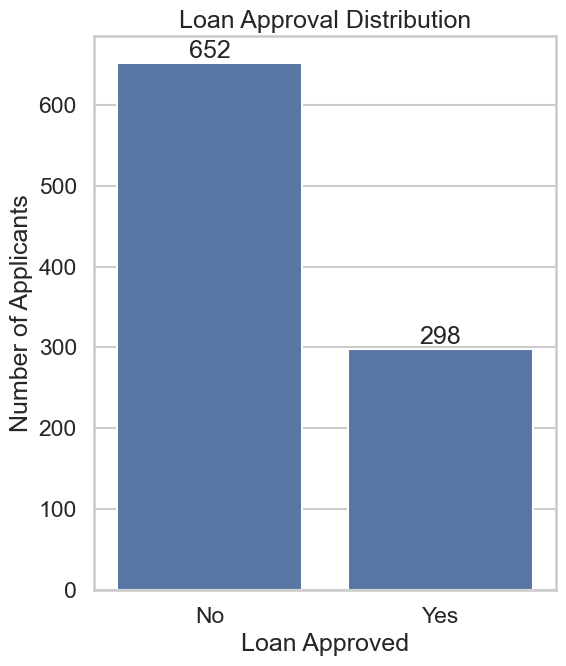

In [49]:
plt.figure(figsize=(6, 7))

ax = sns.countplot(x='Loan_Approved', data=df_eda)
ax.bar_label(ax.containers[0])

plt.title('Loan Approval Distribution')
plt.xlabel('Loan Approved')
plt.ylabel('Number of Applicants')

plt.tight_layout()

plt.show()

In [50]:
plt.savefig('../plots/approval_distribution.png')

<Figure size 640x480 with 0 Axes>

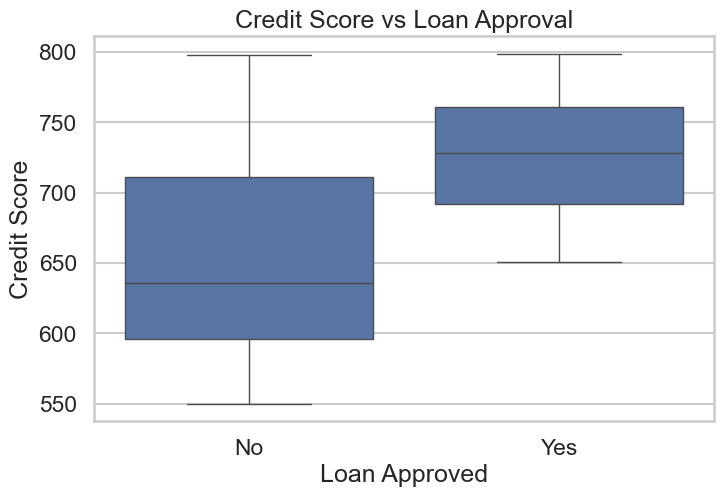

In [51]:
plt.figure(figsize=(8, 5))

sns.boxplot(x='Loan_Approved', y='Credit_Score', data=df_eda)

plt.title('Credit Score vs Loan Approval')
plt.xlabel('Loan Approved')
plt.ylabel('Credit Score')

plt.show()

In [52]:
plt.savefig('../plots/credit_vs_approval.png')

<Figure size 640x480 with 0 Axes>

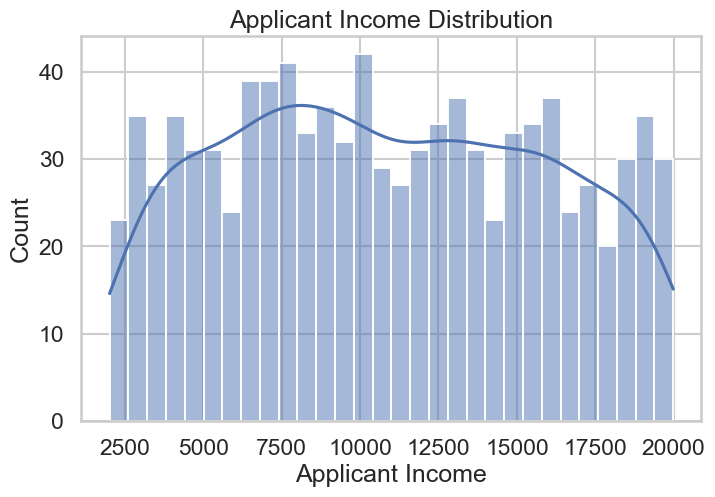

In [53]:
plt.figure(figsize=(8, 5))

sns.histplot(df_eda['Applicant_Income'], bins=30, kde=True)

plt.title('Applicant Income Distribution')
plt.xlabel('Applicant Income')

plt.show()

In [54]:
plt.savefig('../plots/income_distribution.png')

<Figure size 640x480 with 0 Axes>

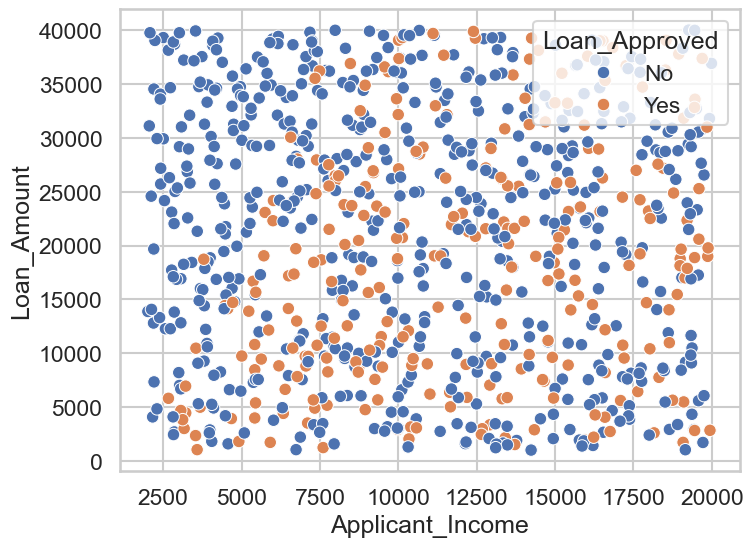

In [55]:
plt.figure(figsize=(8, 6))

sns.scatterplot(x='Applicant_Income', y='Loan_Amount', data=df_eda, hue='Loan_Approved')

plt.show()

In [56]:
plt.savefig('../plots/income_vs_loan')

<Figure size 640x480 with 0 Axes>

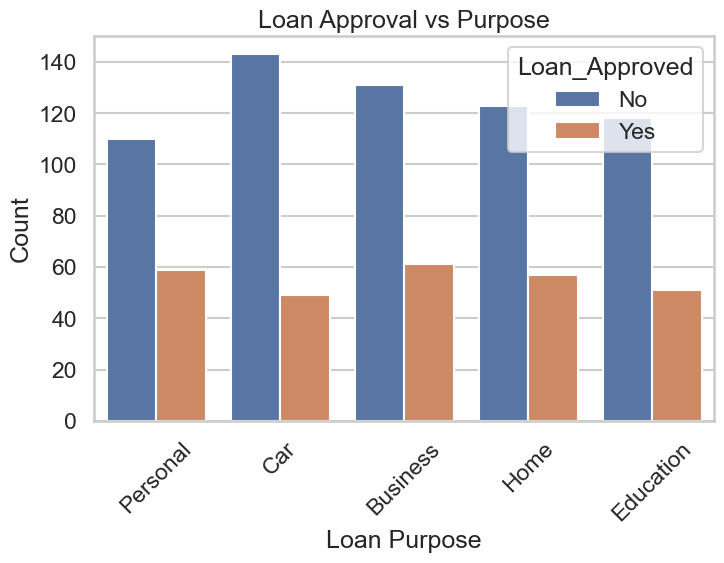

In [57]:
plt.figure(figsize=(8, 5))

sns.countplot(x='Loan_Purpose', hue='Loan_Approved', data=df_eda)

plt.title('Loan Approval vs Purpose')
plt.xlabel('Loan Purpose')
plt.ylabel('Count')

plt.xticks(rotation=45)

plt.show()

In [2]:
import matplotlib.pyplot as plt
plt.savefig('../plots/purpose_vs_approval.png')

<Figure size 640x480 with 0 Axes>

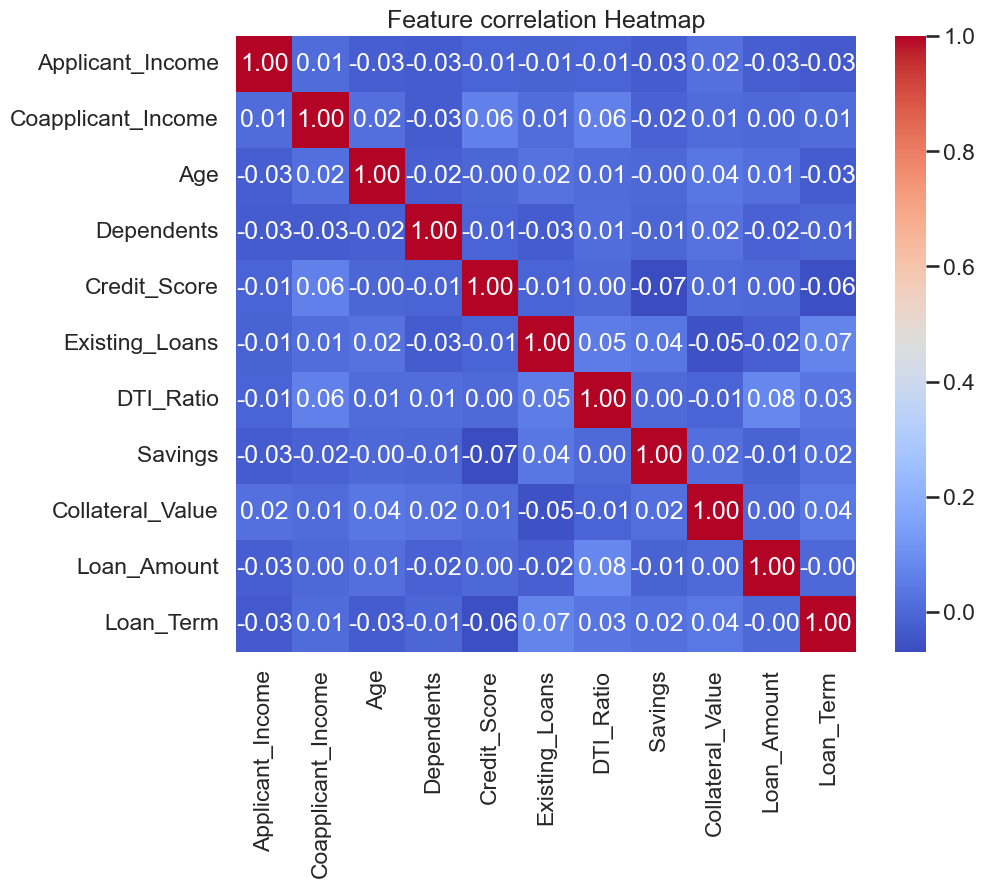

In [59]:
plt.figure(figsize=(10, 8))

corr = df_eda.drop('Applicant_ID', axis=1).corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')

plt.title('Feature correlation Heatmap')

plt.show()

In [60]:
plt.savefig('../plots/heatmap.png')

<Figure size 640x480 with 0 Axes>

In [ ]:
df.to_csv('../data/preprocessed_data.csv', index=False)

In [2]:
import pandas as pd
df = pd.read_csv('../data/preprocessed_data.csv')
df.shape

(950, 31)

In [63]:
df.isnull().sum()

Applicant_Income                   0
Coapplicant_Income                 0
Age                                0
Dependents                         0
Credit_Score                       0
Existing_Loans                     0
DTI_Ratio                          0
Savings                            0
Collateral_Value                   0
Loan_Amount                        0
Loan_Term                          0
Loan_Approved                      0
Total_Income                       0
Loan_Income_Ratio                  0
Savings_Ratio                      0
Employment_Status_Salaried         0
Employment_Status_Self-employed    0
Employment_Status_Unemployed       0
Marital_Status_Single              0
Loan_Purpose_Car                   0
Loan_Purpose_Education             0
Loan_Purpose_Home                  0
Loan_Purpose_Personal              0
Property_Area_Semiurban            0
Property_Area_Urban                0
Gender_Male                        0
Employer_Category_Government       0
E

In [3]:
X = df.drop('Loan_Approved', axis=1)
y = df['Loan_Approved']

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)



In [5]:
numeric_cols = [
    "Applicant_Income",
    "Coapplicant_Income",
    "Age",
    "Dependents",
    "Credit_Score",
    "Existing_Loans",
    "DTI_Ratio",
    "Savings",
    "Collateral_Value",
    "Loan_Amount",
    "Loan_Term",
    "Total_Income",
    "Loan_Income_Ratio",
    "Savings_Ratio"
]

In [6]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

In [68]:
import joblib
joblib.dump(scaler, '../models/scaler.pkl')

['../models/scaler.pkl']

In [7]:
X_train.shape

(760, 30)

In [70]:
feature_names = X.columns.tolist()
joblib.dump(feature_names, '../models/feature_columns.pkl')

['../models/feature_columns.pkl']

In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score, 
    roc_auc_score,
    confusion_matrix
)

In [9]:
models = {
    "Logistic_Regression": LogisticRegression(class_weight='balanced', max_iter=1000),
    "Naive_Bias": GaussianNB(),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Random_Forest": RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=42),
    "XGBoost": XGBClassifier(n_estimators=200, learning_rate=0.05, max_depth=6, random_state=42, eval_metrics='logloss')
}

In [11]:
df

,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,...,Loan_Purpose_Home,Loan_Purpose_Personal,Property_Area_Semiurban,Property_Area_Urban,Gender_Male,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed,Education_Level_Not Graduate
0,17795.00000,1387.0,51.0,0.0,637.0,4.0,0.53,19403.000000,45638.0,16619.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0
1,2860.00000,2679.0,46.0,3.0,621.0,2.0,0.30,2580.000000,49272.0,38687.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
2,7390.00000,2106.0,25.0,2.0,674.0,4.0,0.20,13844.000000,6908.0,27943.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
3,13964.00000,8173.0,40.0,2.0,579.0,3.0,0.31,9553.000000,10844.0,27819.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,13284.00000,4223.0,31.0,2.0,721.0,1.0,0.29,9386.000000,37629.0,12741.0,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
945,10847.01663,9092.0,58.0,0.0,557.0,0.0,0.59,5370.000000,43563.0,8311.0,...,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0
946,3279.00000,6356.0,58.0,1.0,646.0,3.0,0.19,9966.298557,18361.0,22563.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
947,15192.00000,8433.0,48.0,1.0,666.0,1.0,0.40,8581.000000,41335.0,16203.0,...,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
948,9083.00000,7380.0,50.0,1.0,748.0,3.0,0.31,13491.000000,8933.0,10290.0,...,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0


In [10]:
results = []
trained_models = {}

for name, model in models.items():
    model.fit(X_train, y_train)

    preds = model.predict(X_test)
    probs = model.predict_proba(X_test)[:,1]

    accuracy = accuracy_score(y_test, preds)
    precision = precision_score(y_test, preds)
    recall = recall_score(y_test, preds)
    f1 = f1_score(y_test, preds)
    roc_auc = roc_auc_score(y_test, probs)

    results.append({
        "model": name,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1_score": f1,
        "roc_auc": roc_auc
    })
    
    trained_models[name] = model

c:\Users\upate\OneDrive\Desktop\Projects\AI-loan-approval\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [11:19:09] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "eval_metrics" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [11]:
results_df = pd.DataFrame(results)

results_df.sort_values(by="roc_auc", ascending=False)

,model,accuracy,precision,recall,f1_score,roc_auc
4,XGBoost,0.957895,0.906250,0.966667,0.935484,0.987821
3,Random_Forest,0.942105,0.915254,0.900000,0.907563,0.981154
1,Naive_Bias,0.873684,0.821429,0.766667,0.793103,0.945513
0,Logistic_Regression,0.852632,0.716216,0.883333,0.791045,0.932692
2,KNN,0.810526,0.706897,0.683333,0.694915,0.849103


In [12]:
import json

metrics_dict = results_df.set_index("model").to_dict(orient="index")

with open('../plots/model_metrics.json', 'w') as f:
    json.dump(metrics_dict, f, indent=4)

In [13]:
import joblib

for name, model in trained_models.items():
    joblib.dump(model, f'../models/{name}.pkl')

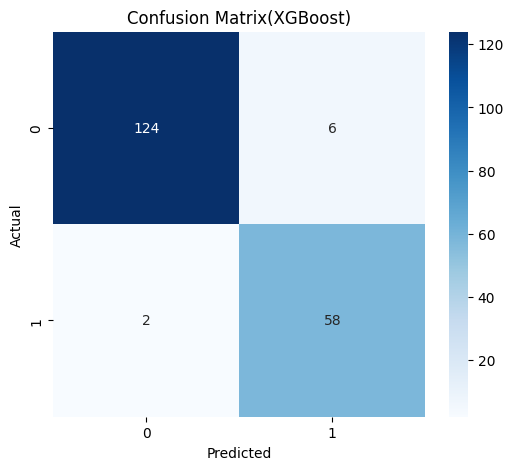

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

best_model = trained_models["XGBoost"]

preds = best_model.predict(X_test)

cm = confusion_matrix(y_test, preds)

plt.figure(figsize=(6, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title('Confusion Matrix(XGBoost)')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

In [16]:
plt.savefig('../plots/cm.png')

<Figure size 640x480 with 0 Axes>

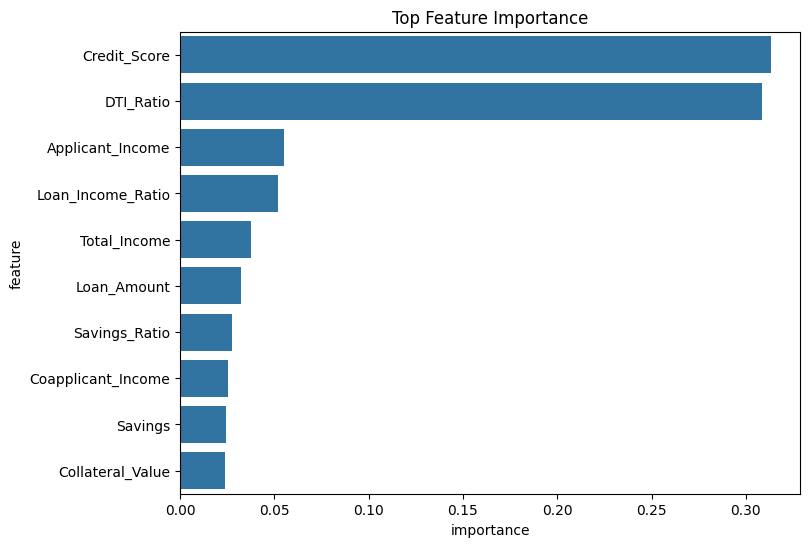

In [17]:
rf = trained_models['Random_Forest']

importances = rf.feature_importances_
features = X_train.columns

importance_df = pd.DataFrame({
    "feature": features,
    "importance": importances
}).sort_values(by="importance", ascending=False)

plt.figure(figsize=(8, 6))

sns.barplot(x='importance', y='feature', data=importance_df.head(10))

plt.title('Top Feature Importance')

plt.show()

In [18]:
plt.savefig('../plots/feature_importance.png')

<Figure size 640x480 with 0 Axes>

In [6]:
import pandas as pd

df = pd.read_csv('../data/preprocessed_data.csv')

df.head

<bound method NDFrame.head of      Applicant_Income  Coapplicant_Income   Age  Dependents  Credit_Score  \
0         17795.00000              1387.0  51.0         0.0         637.0   
1          2860.00000              2679.0  46.0         3.0         621.0   
2          7390.00000              2106.0  25.0         2.0         674.0   
3         13964.00000              8173.0  40.0         2.0         579.0   
4         13284.00000              4223.0  31.0         2.0         721.0   
..                ...                 ...   ...         ...           ...   
945       10847.01663              9092.0  58.0         0.0         557.0   
946        3279.00000              6356.0  58.0         1.0         646.0   
947       15192.00000              8433.0  48.0         1.0         666.0   
948        9083.00000              7380.0  50.0         1.0         748.0   
949       13093.00000              2385.0  23.0         1.0         613.0   

     Existing_Loans  DTI_Ratio       Savings 

In [8]:
df['Credit_Score'].mean()
df['Loan_Amount'].mean()

np.float64(20455.89590254707)

In [16]:
df['Applicant_Income'].min()

np.float64(2009.0)